# M5 Demand Forecast — EDA

All modelling logic lives in `src/forecast/`. This notebook only explores the ingested slice.

In [1]:
import pandas as pd
from pathlib import Path

ROOT = Path("..").resolve()
processed = ROOT / "data" / "processed"

long = pd.read_parquet(processed / "sales_long.parquet")
meta = pd.read_parquet(processed / "series_meta.parquet")
print(f"Series: {long['id'].nunique()}, days: {long['day_idx'].nunique()}")

Series: 200, days: 1969


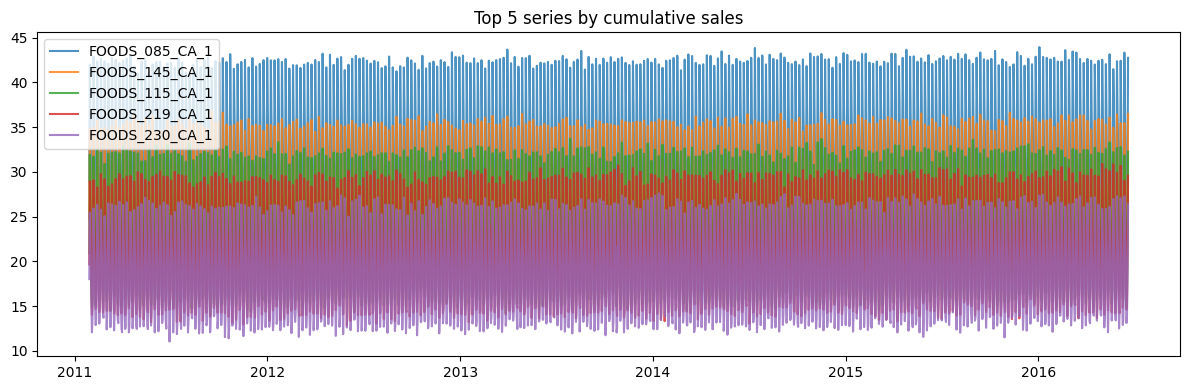

In [2]:
import matplotlib.pyplot as plt

top = meta.nlargest(5, "weight")["id"].tolist()
fig, ax = plt.subplots(figsize=(12, 4))
for sid in top:
    s = long[long["id"] == sid]
    ax.plot(s["date"], s["sales"], label=sid, alpha=0.8)
ax.legend()
ax.set_title("Top 5 series by cumulative sales")
plt.tight_layout()

In [3]:
from forecast.features import build_features
from forecast.config import load_config

cfg = load_config(ROOT / "configs" / "default.yaml")
featured = build_features(
    long,
    lags=cfg["features"]["lags"],
    rolling_windows=cfg["features"]["rolling_windows"],
    min_lag=cfg["features"]["min_lag"],
)
featured[["id", "day_idx", "sales", "lag_28", "snap"]].tail(10)

,id,day_idx,sales,lag_28,snap
393790,FOODS_246_CA_1,1960,1.414098,2.130327,0
393791,FOODS_246_CA_1,1961,3.193312,3.412276,0
393792,FOODS_246_CA_1,1962,3.320917,4.199279,1
393793,FOODS_246_CA_1,1963,4.071794,3.419501,0
393794,FOODS_246_CA_1,1964,3.397129,2.442598,0
393795,FOODS_246_CA_1,1965,2.618390,2.079939,0
393796,FOODS_246_CA_1,1966,1.949460,1.807532,0
393797,FOODS_246_CA_1,1967,2.231504,1.842887,0
393798,FOODS_246_CA_1,1968,1.533327,2.975081,0
393799,FOODS_246_CA_1,1969,3.307020,3.255285,1
